# Downside and stress selection

This notebook implements NB12 from `steady-vault-plan-01.md`. P1 from NB11 is
the frozen parent: the downside arms do not change the profitability
qualification or invent a new return rank. D0 is the P1 sizing-only control;
D1 screens observed downside; D2 adds a volatility screen; D3 reduces an
otherwise eligible target after an observed 180-day drawdown stress event.

The full research panel and the retrospective A0b allowlist are both run.
Daily decisions use only the point-in-time NB11 signals, and the replay uses
the same equal-weight, 20% individual cap, TVL capacity cap, residual-cash and
blocked-holder retention rules. NAV share prices have no invented slippage,
liquidation cost or blanket fee. Missing risk evidence is reported as missing
and does not become a favourable zero-risk value. A0b remains the independent
reproduction control; this notebook's equal-weight arms are a selection
diagnostic, not a claim to reproduce its inverse-risk sizing. D0 is checked
against the NB11 P1 equity and target ledgers after replay.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
NB11 = PROJECT_DIR / "_artifacts-profitability-repeatability"
OUT = PROJECT_DIR / "_artifacts-downside-stress"
OUT.mkdir(exist_ok=True)

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
INITIAL_CASH = 150_000.0
TARGET_DEPLOYMENT = 0.98
MAX_WEIGHT = 0.20
MAX_TVL_FRACTION = 0.33
MAX_NAMES = 20
EXECUTION_EVERY_DAYS = 2
RISK_WINDOWS = (60, 30, 14)

SIGNALS = pd.read_parquet(NB11 / "point_in_time-selection-signals.parquet")
SIGNALS["date"] = pd.to_datetime(SIGNALS.date).dt.normalize()
SIGNALS["address"] = SIGNALS.address.astype(str).str.lower()
# Missingness indicator columns were useful to NB11's model diagnostics but
# are not inputs to this fixed risk-screen replay. Dropping them here keeps
# the two universe copies bounded in memory without changing any used value.
SIGNALS = SIGNALS.drop(columns=[column for column in SIGNALS if column.endswith("__missing")], errors="ignore").copy()
OBS = pd.read_parquet(REWRITE / "observations.parquet")
OBS["address"] = OBS.address.astype(str).str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
OBS = OBS[OBS.is_fresh & OBS.share_price.gt(0)].sort_values(["address", "timestamp"])
METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.astype(str).str.lower()
METADATA = METADATA.drop_duplicates("address").set_index("address")

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
universe_json = json.loads(UNIVERSE_CACHE.read_text())
universe_items = universe_json.get("vaults", universe_json) if isinstance(universe_json, dict) else universe_json
A0B_ALLOWLIST = {str(item["address"]).lower() for item in universe_items if "address" in item}
A0B_ALLOWLIST.discard("0x5290ab34acb59cfe1371baa5782eba14433d308f")
UNIVERSES = {"full_panel": set(SIGNALS.address.unique()), "a0b_allowlist": A0B_ALLOWLIST}
print({"signals": SIGNALS.shape, "observations": OBS.shape, "universes": {k: len(v) for k, v in UNIVERSES.items()}})


{'signals': (104618, 234), 'observations': (487738, 9), 'universes': {'full_panel': 532, 'a0b_allowlist': 338}}


## Causal risk measurements

The parent signal was generated in NB11 using observations available at each
row's `last_observation_ts`; forward labels are not loaded here. The long
window is preferred and falls back to 30 and 14 days. Existing daily risk
columns are populated only when the source has the required consecutive daily
coverage. A finite value is therefore required to pass D1/D2. For a young or
sparse vault, a missing value remains an evidence gap rather than a clean
record.

D1 requires observed drawdown no worse than -3%. D2 requires D1 and observed
annualised daily volatility no higher than 8%. `risk_window` records which
fallback was actually used. The 180-day stress series is computed from raw
fresh marks with a trailing time window and joined backward to the last
observation known at the decision; it cannot see a later mark. D3 uses the
worst drawdown observed within that available trailing history, so a recovered
drawdown remains a stress flag until it rolls out of the window.


In [2]:
def finite(value):
    return pd.notna(value) and np.isfinite(float(value))


def preferred_value(row, stem):
    for window in RISK_WINDOWS:
        value = getattr(row, f"{stem}_{window}", np.nan)
        if finite(value):
            return float(value), int(window)
    return np.nan, np.nan


def trailing_stress_marks(observations):
    rows = []
    for address, group in observations.groupby("address", sort=False):
        series = group.set_index("timestamp")["share_price"].resample("1D").last().dropna()
        if len(series) < 2:
            continue
        # rolling() includes only marks at or before its right endpoint. A
        # missing calendar date contributes no fabricated price or return.
        rolling_peak = series.rolling("180D", min_periods=2).max()
        current_stress = series / rolling_peak - 1.0
        # D3 is a history stress rule: a vault remains stress-flagged after
        # recovering from a drawdown until that event rolls out of the
        # available 180-day window.
        stress_history = current_stress.rolling("180D", min_periods=1).min()
        rows.append(pd.DataFrame({"address": address, "stress_timestamp": stress_history.index, "stress_dd_180": stress_history.to_numpy(), "current_dd_180": current_stress.to_numpy()}))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["address", "stress_timestamp", "stress_dd_180", "current_dd_180"])


STRESS_MARKS = trailing_stress_marks(OBS)
stress_parts = []
for address, group in SIGNALS.groupby("address", sort=False):
    left = group.sort_values("last_observation_ts").copy()
    left["last_observation_ts"] = pd.to_datetime(left["last_observation_ts"]).astype("datetime64[ns]")
    right = STRESS_MARKS[STRESS_MARKS.address.eq(address)].sort_values("stress_timestamp")
    if right.empty:
        left["stress_dd_180"] = np.nan
        left["current_dd_180"] = np.nan
    else:
        right = right.copy()
        right["stress_timestamp"] = pd.to_datetime(right["stress_timestamp"]).astype("datetime64[ns]")
        left = pd.merge_asof(left, right[["stress_timestamp", "stress_dd_180", "current_dd_180"]], left_on="last_observation_ts", right_on="stress_timestamp", direction="backward")
    stress_parts.append(left)
SIGNALS = pd.concat(stress_parts, ignore_index=True).sort_values(["date", "address"]).reset_index(drop=True)

risk_rows = []
for row in SIGNALS.itertuples(index=False):
    drawdown, dd_window = preferred_value(row, "daily_max_dd")
    volatility, vol_window = preferred_value(row, "daily_vol")
    risk_window = dd_window if finite(dd_window) else vol_window
    p1 = bool(getattr(row, "p1", False))
    d1 = p1 and finite(drawdown) and drawdown >= -0.03
    d2 = d1 and finite(volatility) and volatility <= 0.08
    risk_rows.append({
        "date": row.date,
        "address": row.address,
        "p1": p1,
        "drawdown_observed": drawdown,
        "drawdown_window_days": dd_window,
        "volatility_observed": volatility,
        "volatility_window_days": vol_window,
        "risk_window_days": risk_window,
        "d1": bool(d1),
        "d2": bool(d2),
        "d1_missing": bool(p1 and not finite(drawdown)),
        "d2_missing": bool(d1 and not finite(volatility)),
        "stress_dd_180": row.stress_dd_180,
        "current_dd_180": row.current_dd_180,
        "stress_observed": finite(row.stress_dd_180),
        "stress_triggered": bool(finite(row.stress_dd_180) and row.stress_dd_180 < -0.08),
        "young": bool(finite(getattr(row, "available_history_days", np.nan)) and row.available_history_days < 90),
        "last_interval_days": getattr(row, "last_interval_days", np.nan),
    })
RISK = pd.DataFrame(risk_rows)
SIGNALS = SIGNALS.merge(RISK, on=["date", "address"], how="left", suffixes=("", "_risk"), validate="one_to_one")
SIGNALS.to_parquet(OUT / "point_in_time-risk-signals.parquet", index=False)
RISK.to_csv(OUT / "risk-signals.csv", index=False)
display(RISK[["p1", "drawdown_window_days", "volatility_window_days", "d1", "d2", "d1_missing", "d2_missing", "stress_triggered"]].value_counts(dropna=False).rename("rows").reset_index())


,p1,drawdown_window_days,volatility_window_days,d1,d2,d1_missing,d2_missing,stress_triggered,rows
0,False,60.0,60.0,False,False,False,False,True,28060
1,False,NaN,NaN,False,False,False,False,True,27768
2,False,NaN,NaN,False,False,False,False,False,9824
3,True,60.0,60.0,False,False,False,False,True,7152
4,True,NaN,NaN,False,False,True,False,True,6323
5,False,30.0,30.0,False,False,False,False,True,4984
6,False,60.0,60.0,False,False,False,False,False,4646
7,True,NaN,NaN,False,False,True,False,False,3427
8,False,14.0,14.0,False,False,False,False,True,2151
9,False,60.0,NaN,False,False,False,False,False,1297


## Frozen P1 parent and downside arms

The D0 arm inherits the saved NB11 P1 selection exactly. D1 and D2 remove
names failing their risk test and refill from the same P1 parent in the saved
P1 order. This preserves the parent growth rank and avoids selecting a best
downside result retrospectively. D3 uses the D1 basket and halves each
observed-stress name's requested target when its causal 180-day drawdown is
worse than 8%; the released amount stays in cash. Unknown stress is not
treated as a trigger or a pass claim and is reported separately.


In [3]:
ARMS = ("D0", "D1", "D2", "D3")


def build_selection(universe_name, arm):
    addresses = UNIVERSES[universe_name]
    frame = SIGNALS[SIGNALS.address.isin(addresses)].copy()
    frame["parent_qualified"] = frame.p1.fillna(False)
    frame["qualified"] = frame.parent_qualified
    if arm == "D1":
        frame["qualified"] &= frame.d1.fillna(False)
    elif arm in ("D2", "D3"):
        frame["qualified"] &= frame.d2.fillna(False) if arm == "D2" else frame.d1.fillna(False)
    frame["selected"] = False
    frame["selection_rank"] = np.nan
    # NB11 saves selection_rank only for its top-20 names.  A downside arm
    # must be able to refill from the rest of the frozen P1 pool in the same
    # deterministic order, so reconstruct that parent order for all P1 rows.
    frame["parent_selection_order"] = np.nan
    for date, indexes in frame.groupby("date", sort=True).groups.items():
        day = frame.loc[indexes]
        parent_pool = day[day.parent_qualified].sort_values(["ranking_growth", "ranking_downside", "address"], ascending=[False, True, True], kind="stable")
        frame.loc[parent_pool.index, "parent_selection_order"] = np.arange(1, len(parent_pool) + 1)
        if arm == "D0":
            # This is an exact parent control, including the parent top-20
            # cutoff, rather than a fresh rank hidden in a downstream arm.
            chosen = day[day.parent_selected.fillna(False)].copy()
        else:
            # Preserve the frozen P1 return rank while applying the risk
            # screen.  Re-ranking by an outcome-derived downside statistic
            # would silently turn this notebook into a new optimiser.
            chosen = day[day.qualified].sort_values(["parent_selection_order", "address"], ascending=[True, True], kind="stable").head(MAX_NAMES)
        frame.loc[chosen.index, "selected"] = True
        if len(chosen):
            frame.loc[chosen.index, "selection_rank"] = np.arange(1, len(chosen) + 1)
    frame["arm"] = arm
    return frame


SELECTIONS = {}
selection_rows = []
for universe_name in UNIVERSES:
    # Keep NB11 P1's saved selection in the frame for the D0 exact-control
    # branch; NB11's parquet contains the same date/address rows and rank.
    p1_path = NB11 / f"selection-{universe_name}-P1.parquet"
    parent = pd.read_parquet(p1_path)
    parent["date"] = pd.to_datetime(parent.date).dt.normalize()
    parent["address"] = parent.address.astype(str).str.lower()
    parent = parent[["date", "address", "selected", "selection_rank"]].rename(columns={"selected": "parent_selected", "selection_rank": "parent_selection_rank"})
    base = SIGNALS[SIGNALS.address.isin(UNIVERSES[universe_name])].drop(columns=["parent_selected", "parent_selection_rank"], errors="ignore").merge(parent, on=["date", "address"], how="left", validate="one_to_one")
    SIGNALS_backup = SIGNALS
    SIGNALS = base
    for arm in ARMS:
        result = build_selection(universe_name, arm)
        # Replace the temporary D0 lookup with the saved parent flag.
        result["parent_selected"] = result.parent_selected.fillna(False)
        if arm == "D0":
            result["selected"] = result.parent_selected
            result.loc[result.selected, "selection_rank"] = result.loc[result.selected, "parent_selection_rank"]
        SELECTIONS[(universe_name, arm)] = result
        result.to_parquet(OUT / f"selection-{universe_name}-{arm}.parquet", index=False)
        selection_rows.append({"universe": universe_name, "arm": arm, "rows": len(result), "dates": int(result.date.nunique()), "p1_rows": int(result.parent_qualified.sum()), "qualified_rows": int(result.qualified.sum()), "selected_rows": int(result.selected.sum()), "selected_dates": int(result.loc[result.selected, "date"].nunique()), "d1_missing_rows": int((result.parent_qualified & result.d1_missing.fillna(False)).sum()), "d2_missing_rows": int((result.d1 & result.d2_missing.fillna(False)).sum())})
    SIGNALS = SIGNALS_backup
selection_summary = pd.DataFrame(selection_rows)
selection_summary.to_csv(OUT / "selection-summary.csv", index=False)
display(selection_summary)


,universe,arm,rows,dates,p1_rows,qualified_rows,selected_rows,selected_dates,d1_missing_rows,d2_missing_rows
0,full_panel,D0,104618,545,21775,21775,10561,545,9750,9
1,full_panel,D1,104618,545,21775,2896,2874,226,9750,9
2,full_panel,D2,104618,545,21775,954,954,224,9750,9
3,full_panel,D3,104618,545,21775,2896,2874,226,9750,9
4,a0b_allowlist,D0,61891,545,13701,13701,9384,545,5694,0
5,a0b_allowlist,D1,61891,545,13701,2201,2192,223,5694,0
6,a0b_allowlist,D2,61891,545,13701,748,748,216,5694,0
7,a0b_allowlist,D3,61891,545,13701,2201,2192,223,5694,0


## Equal-weight replay with residual cash

This replay is intentionally small and transparent. It forward-fills marks
from fresh NAV observations for valuation, while signal and risk eligibility
remain point-in-time rows. It executes every second day, requests equal
weights, clips each name at 20% of equity and at 33% of current TVL, and
leaves all rejected capacity in cash. D3 applies its half-weight rule without
redistributing the released cash. There is no synthetic trading friction.


In [4]:
def finite_value(value):
    return pd.notna(value) and np.isfinite(float(value))


def build_daily_marks(observations, dates):
    marks = observations.assign(calendar_date=observations.timestamp.dt.normalize()).groupby(["calendar_date", "address"]).share_price.last().unstack("address")
    index = marks.index.union(dates).sort_values()
    return marks.reindex(index).sort_index().ffill().reindex(dates)


BLOCKED = set()
if "redemption_closed_reason" in METADATA:
    blocked_values = METADATA.redemption_closed_reason.astype("string")
    BLOCKED = set(METADATA.index[blocked_values.notna() & blocked_values.str.strip().ne("")])


def replay(selection, start, end, universe_name, arm):
    dates = pd.date_range(start, end, freq="D")
    marks = build_daily_marks(OBS, dates)
    execution_dates = set(dates[::EXECUTION_EVERY_DAYS])
    rows, target_rows = [], []
    cash = INITIAL_CASH
    units = {}
    last_prices = {}
    for date in dates:
        day_prices = marks.loc[date] if date in marks.index else pd.Series(dtype=float)
        for address, price in day_prices.dropna().items():
            last_prices[address] = float(price)
        marked = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        equity = cash + sum(marked.values())
        target = dict(marked)
        turnover = 0.0
        stress_triggered_positions = 0
        blocked_positions = 0
        if date in execution_dates:
            day = selection[selection.date.eq(date)].set_index("address")
            chosen = day[day.selected].copy()
            investable = max(equity * TARGET_DEPLOYMENT, 0.0)
            requested = investable / len(chosen) if len(chosen) else 0.0
            target = {address: value for address, value in marked.items() if address in BLOCKED}
            for address, item in chosen.iterrows():
                if address in BLOCKED and address in target:
                    continue
                accepted = requested
                stress_factor = 0.5 if arm == "D3" and bool(item.stress_triggered) else 1.0
                accepted = accepted * stress_factor
                tvl = float(item.tvl_current) if finite_value(item.tvl_current) else 0.0
                capacity = min(equity * MAX_WEIGHT, MAX_TVL_FRACTION * tvl)
                accepted = max(min(accepted, capacity), 0.0)
                if address in last_prices:
                    target[address] = accepted
                target_rows.append({"date": date, "universe": universe_name, "arm": arm, "address": address, "parent_qualified": bool(item.parent_qualified), "qualified": bool(item.qualified), "selected": True, "selection_rank": item.selection_rank, "requested_dollars": requested, "stress_factor": stress_factor, "accepted_dollars": accepted, "cap_binding": accepted + 1e-8 < requested * stress_factor, "tvl_current": item.tvl_current, "drawdown_observed": item.drawdown_observed, "volatility_observed": item.volatility_observed, "stress_dd_180": item.stress_dd_180, "current_dd_180": item.current_dd_180, "stress_observed": bool(item.stress_observed), "blocked": address in BLOCKED})
            stress_triggered_positions = int(chosen.loc[chosen.index.isin(target), "stress_triggered"].fillna(False).sum())
            blocked_positions = int(sum(address in BLOCKED for address in target))
            cash = max(equity - sum(target.values()), 0.0)
            turnover = float(sum(abs(target.get(address, 0) - marked.get(address, 0)) for address in set(target) | set(marked)))
            units = {address: value / last_prices[address] for address, value in target.items() if value > 0 and address in last_prices}
            equity = cash + sum(value for address, value in target.items() if address in last_prices)
        invested = max(equity - cash, 0.0)
        weights = pd.Series({address: value / invested for address, value in target.items()}) if invested > 0 else pd.Series(dtype=float)
        rows.append({"date": date, "equity": equity, "cash": cash, "cash_fraction": cash / equity if equity else np.nan, "invested": invested, "n_positions": len(target), "effective_positions": float(1 / weights.pow(2).sum()) if len(weights) and weights.pow(2).sum() > 0 else 0.0, "turnover": turnover, "execution_date": date in execution_dates, "stress_triggered_positions": stress_triggered_positions, "blocked_positions": blocked_positions, "universe": universe_name, "arm": arm})
    curve = pd.DataFrame(rows)
    curve["return"] = curve.equity.pct_change()
    curve["drawdown"] = curve.equity / curve.equity.cummax() - 1
    return curve, pd.DataFrame(target_rows)


def metrics(curve, periods_per_year=365.0):
    if curve.empty:
        return {}
    returns = curve["return"].dropna()
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    std = returns.std(ddof=1)
    return {"start": curve.date.iloc[0], "end": curve.date.iloc[-1], "final_equity": float(curve.equity.iloc[-1]), "cagr": float((curve.equity.iloc[-1] / curve.equity.iloc[0]) ** (365.0 / span_days) - 1), "volatility": float(std * math.sqrt(periods_per_year)) if finite_value(std) else np.nan, "sharpe": float(returns.mean() / std * math.sqrt(periods_per_year)) if finite_value(std) and std > 0 else np.nan, "max_drawdown": float(curve.drawdown.min()), "ulcer": float(np.sqrt(np.mean(curve.drawdown.pow(2)))), "mean_cash_fraction": float(curve.cash_fraction.mean()), "mean_positions": float(curve.n_positions.mean()), "mean_effective_positions": float(curve.effective_positions.mean()), "mean_turnover": float(curve.turnover.mean()), "stress_triggered_position_days": int(curve.stress_triggered_positions.sum()), "blocked_position_days": int(curve.blocked_positions.sum())}


def weekly_curve(curve):
    weekly = curve.assign(week=curve.date.dt.to_period("W-SUN").dt.end_time.dt.normalize()).sort_values("date").groupby("week", as_index=False).last()
    weekly["return"] = weekly.equity.pct_change()
    weekly["drawdown"] = weekly.equity / weekly.equity.cummax() - 1
    return weekly


backtest_rows = []
for (universe_name, arm), selection in SELECTIONS.items():
    for period_name, (start, end) in PERIODS.items():
        curve, targets = replay(selection, start, end, universe_name, arm)
        curve.to_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet", index=False)
        targets.to_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet", index=False)
        backtest_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "clock": "daily", **metrics(curve, 365.0)})
        backtest_rows.append({"universe": universe_name, "arm": arm, "period": period_name, "clock": "weekly", **metrics(weekly_curve(curve), 52.0)})
backtest_metrics = pd.DataFrame(backtest_rows)
backtest_metrics.to_csv(OUT / "backtest-metrics.csv", index=False)
display(backtest_metrics.round(4))

# D0 is a sizing-only control. Keep the original NB11 P1 replay as the
# reference and fail loudly if this notebook's copied replay drifts.
parity_rows = []
for universe_name in UNIVERSES:
    for period_name in PERIODS:
        actual = pd.read_parquet(OUT / f"equity-{universe_name}-D0-{period_name}.parquet")
        reference = pd.read_parquet(NB11 / f"equity-{universe_name}-P1-{period_name}.parquet")
        if not actual.date.equals(reference.date):
            raise AssertionError(f"D0/NB11 date mismatch: {universe_name}/{period_name}")
        max_abs_equity_error = float(np.max(np.abs(actual.equity.to_numpy() - reference.equity.to_numpy())))
        np.testing.assert_allclose(actual.equity.to_numpy(), reference.equity.to_numpy(), rtol=1e-10, atol=1e-7)
        actual_targets = pd.read_parquet(OUT / f"targets-{universe_name}-D0-{period_name}.parquet")
        reference_targets = pd.read_parquet(NB11 / f"targets-{universe_name}-P1-{period_name}.parquet")
        if len(actual_targets) != len(reference_targets):
            raise AssertionError(f"D0/NB11 target-row mismatch: {universe_name}/{period_name}: {len(actual_targets)} != {len(reference_targets)}")
        parity_rows.append({"universe": universe_name, "period": period_name, "max_abs_equity_error": max_abs_equity_error, "actual_target_rows": len(actual_targets), "reference_target_rows": len(reference_targets), "status": "pass"})
parity = pd.DataFrame(parity_rows)
parity.to_csv(OUT / "d0-nb11-parity.csv", index=False)
display(parity)


,universe,arm,period,clock,start,end,final_equity,cagr,volatility,sharpe,max_drawdown,ulcer,mean_cash_fraction,mean_positions,mean_effective_positions,mean_turnover,stress_triggered_position_days,blocked_position_days
0,full_panel,D0,hyper_ai,daily,2026-01-01,2026-07-08,152243.1372,0.0292,0.0998,0.3387,-0.0543,0.0262,0.1675,20.0000,18.5886,25280.5357,1220,0
1,full_panel,D0,hyper_ai,weekly,2026-01-04,2026-07-08,152243.1372,0.0297,0.1024,0.3294,-0.0513,0.0253,0.1704,20.0000,18.5746,23061.5889,182,0
2,full_panel,D0,full,daily,2025-09-13,2026-09-12,164926.7055,0.0998,0.1288,0.8015,-0.0544,0.0268,0.1598,20.0000,18.6501,23386.0258,2161,0
3,full_panel,D0,full,weekly,2025-09-14,2026-09-12,164926.7055,0.1001,0.1319,0.7834,-0.0513,0.0261,0.1629,20.0000,18.6203,18893.3188,318,0
4,full_panel,D1,hyper_ai,daily,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,-0.0694,0.0337,0.4047,10.7989,9.3151,18810.0101,560,0
5,full_panel,D1,hyper_ai,weekly,2026-01-04,2026-07-08,149775.0407,-0.0030,0.1285,0.0406,-0.0693,0.0336,0.4038,11.0000,9.5818,16442.4431,88,0
6,full_panel,D1,full,daily,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,-0.0694,0.0275,0.5589,7.8438,6.8276,13242.5774,838,0
7,full_panel,D1,full,weekly,2025-09-14,2026-09-12,155516.6196,0.0370,0.0955,0.4258,-0.0693,0.0272,0.5636,7.8679,6.8866,10949.9628,132,0
8,full_panel,D2,hyper_ai,daily,2026-01-01,2026-07-08,151974.1220,0.0257,0.0237,1.0835,-0.0093,0.0033,0.5643,3.0952,2.5460,10991.2639,102,0
9,full_panel,D2,hyper_ai,weekly,2026-01-04,2026-07-08,151974.1220,0.0261,0.0156,1.6178,-0.0061,0.0023,0.5583,3.2857,2.6516,8859.9394,14,0


,universe,period,max_abs_equity_error,actual_target_rows,reference_target_rows,status
0,full_panel,hyper_ai,0.0,1900,1900,pass
1,full_panel,full,0.0,3660,3660,pass
2,a0b_allowlist,hyper_ai,0.0,1755,1755,pass
3,a0b_allowlist,full,0.0,3452,3452,pass


## Pass rates by age and observation cadence

The pass-rate table is a diagnostic for the age bias of downside screens. A
young vault with no measured risk is counted as missing, not as a D1/D2 pass.
Cadence is descriptive and is not a popularity feature: `dense` means the
last interval is at most two days, `weekly` at most eight days, and `sparse`
is longer or unknown.


In [5]:
def age_bucket(value):
    if not finite_value(value):
        return "unknown"
    if value < 30:
        return "young_<30d"
    if value < 90:
        return "developing_30_90d"
    return "mature_90d+"


def cadence_bucket(value):
    if not finite_value(value):
        return "unknown"
    if value <= 2:
        return "dense_<=2d"
    if value <= 8:
        return "weekly_3_8d"
    return "sparse_>8d"


pass_rows = []
base = SIGNALS[SIGNALS.address.isin(set.union(*UNIVERSES.values()))].copy()
base["age_bucket"] = base.available_history_days.map(age_bucket)
base["cadence_bucket"] = base.last_interval_days.map(cadence_bucket)
for universe_name, addresses in UNIVERSES.items():
    period = base[base.address.isin(addresses)].copy()
    for bucket_name, grouped in period.groupby(["age_bucket", "cadence_bucket"], dropna=False):
        for label, mask in [("P1", grouped.p1.fillna(False)), ("D1", grouped.d1.fillna(False)), ("D2", grouped.d2.fillna(False))]:
            parent_count = int(grouped.p1.fillna(False).sum())
            pass_rows.append({"universe": universe_name, "age_bucket": bucket_name[0], "cadence_bucket": bucket_name[1], "arm": label, "parent_p1_rows": parent_count, "rows": int(mask.sum()), "pass_rate_of_p1": float(mask.sum() / parent_count) if parent_count else np.nan, "d1_missing_rows": int((grouped.p1.fillna(False) & grouped.d1_missing.fillna(False)).sum()) if label == "D1" else np.nan, "d2_missing_rows": int((grouped.d1.fillna(False) & grouped.d2_missing.fillna(False)).sum()) if label == "D2" else np.nan, "stress_observed_rows": int((grouped.p1.fillna(False) & grouped.stress_observed.fillna(False)).sum()) if label == "P1" else np.nan, "stress_triggered_rows": int((grouped.p1.fillna(False) & grouped.stress_triggered.fillna(False)).sum()) if label == "P1" else np.nan})
pass_rates = pd.DataFrame(pass_rows)
pass_rates.to_csv(OUT / "risk-pass-rates-by-age-cadence.csv", index=False)
display(pass_rates)


,universe,age_bucket,cadence_bucket,arm,parent_p1_rows,rows,pass_rate_of_p1,d1_missing_rows,d2_missing_rows,stress_observed_rows,stress_triggered_rows
0,full_panel,developing_30_90d,dense_<=2d,P1,3300,3300,1.000000,NaN,NaN,3300.0,1301.0
1,full_panel,developing_30_90d,dense_<=2d,D1,3300,449,0.136061,1662.0,NaN,NaN,NaN
2,full_panel,developing_30_90d,dense_<=2d,D2,3300,100,0.030303,NaN,8.0,NaN,NaN
3,full_panel,developing_30_90d,sparse_>8d,P1,0,0,NaN,NaN,NaN,0.0,0.0
4,full_panel,developing_30_90d,sparse_>8d,D1,0,0,NaN,0.0,NaN,NaN,NaN
5,full_panel,developing_30_90d,sparse_>8d,D2,0,0,NaN,NaN,0.0,NaN,NaN
6,full_panel,developing_30_90d,weekly_3_8d,P1,202,202,1.000000,NaN,NaN,202.0,99.0
7,full_panel,developing_30_90d,weekly_3_8d,D1,202,0,0.000000,202.0,NaN,NaN,NaN
8,full_panel,developing_30_90d,weekly_3_8d,D2,202,0,0.000000,NaN,0.0,NaN,NaN
9,full_panel,mature_90d+,dense_<=2d,P1,17539,17539,1.000000,NaN,NaN,17539.0,14149.0


## Stress attribution and leader removal

The leader-removal table removes the single largest positive daily equity move
from the portfolio return stream; it is attribution, not a tradable
counterfactual. The stress table shows how often D3 actually released target
capital and how much evidence was unavailable. The result tables distinguish
invested-basket behaviour from cash dilution.


In [6]:
def attribution(curve):
    returns = curve["return"].dropna().copy()
    if len(returns) == 0:
        return {"leader_daily_return": np.nan, "leader_removed_cagr": np.nan, "leader_removed_final_equity": np.nan}
    leader_date = returns.idxmax()
    adjusted = returns.copy()
    adjusted.loc[leader_date] = 0.0
    final = float(INITIAL_CASH * (1 + adjusted).prod())
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    return {"leader_daily_return": float(returns.loc[leader_date]), "leader_date": str(curve.loc[leader_date, "date"].date()), "leader_removed_final_equity": final, "leader_removed_cagr": float((final / INITIAL_CASH) ** (365.0 / span_days) - 1)}


attribution_rows = []
for (universe_name, arm), selection in SELECTIONS.items():
    for period_name, (start, end) in PERIODS.items():
        curve = pd.read_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet")
        attribution_rows.append({"universe": universe_name, "arm": arm, "period": period_name, **attribution(curve), "mean_stress_triggered_positions": float(curve.stress_triggered_positions.mean()), "stress_triggered_days": int((curve.stress_triggered_positions > 0).sum())})
attribution_table = pd.DataFrame(attribution_rows)
attribution_table.to_csv(OUT / "stress-and-leader-attribution.csv", index=False)
display(attribution_table.round(4))


,universe,arm,period,leader_daily_return,leader_date,leader_removed_final_equity,leader_removed_cagr,mean_stress_triggered_positions,stress_triggered_days
0,full_panel,D0,hyper_ai,0.0223,2026-01-19,148915.5599,-0.0140,6.4550,95
1,full_panel,D0,full,0.0859,2025-10-15,151876.5619,0.0125,5.9205,183
2,full_panel,D1,hyper_ai,0.0235,2026-05-23,146342.6155,-0.0468,2.9630,78
3,full_panel,D1,full,0.0235,2026-05-23,151952.6134,0.0131,2.2959,111
4,full_panel,D2,hyper_ai,0.0059,2026-05-23,151080.1442,0.0140,0.5397,62
5,full_panel,D2,full,0.0059,2026-05-23,151770.3991,0.0118,0.5973,95
6,full_panel,D3,hyper_ai,0.0132,2026-05-23,144415.9999,-0.0710,2.9630,78
7,full_panel,D3,full,0.0132,2026-05-23,146974.7306,-0.0202,2.2959,111
8,a0b_allowlist,D0,hyper_ai,0.0150,2026-02-21,132817.6811,-0.2104,6.4709,95
9,a0b_allowlist,D0,full,0.0332,2025-10-08,136133.0471,-0.0927,6.1616,183


## Results and limitations

D0 is the frozen P1 control. D1 and D2 can reduce coverage because a short or
sparse history cannot establish the requested risk statistic. That behaviour
is intentional; the young/sparse evidence sleeves are tested in NB14. The
allowlist is a retrospective current snapshot, so the full-panel rows are the
important universe sensitivity. Daily risk on carried NAVs can understate
unobserved intraperiod stress; weekly and stale-capital diagnostics must be
read with the curves. Results are descriptive historical replay, not a
guarantee of future Sharpe or a proof that a -3%/-8% threshold is optimal.


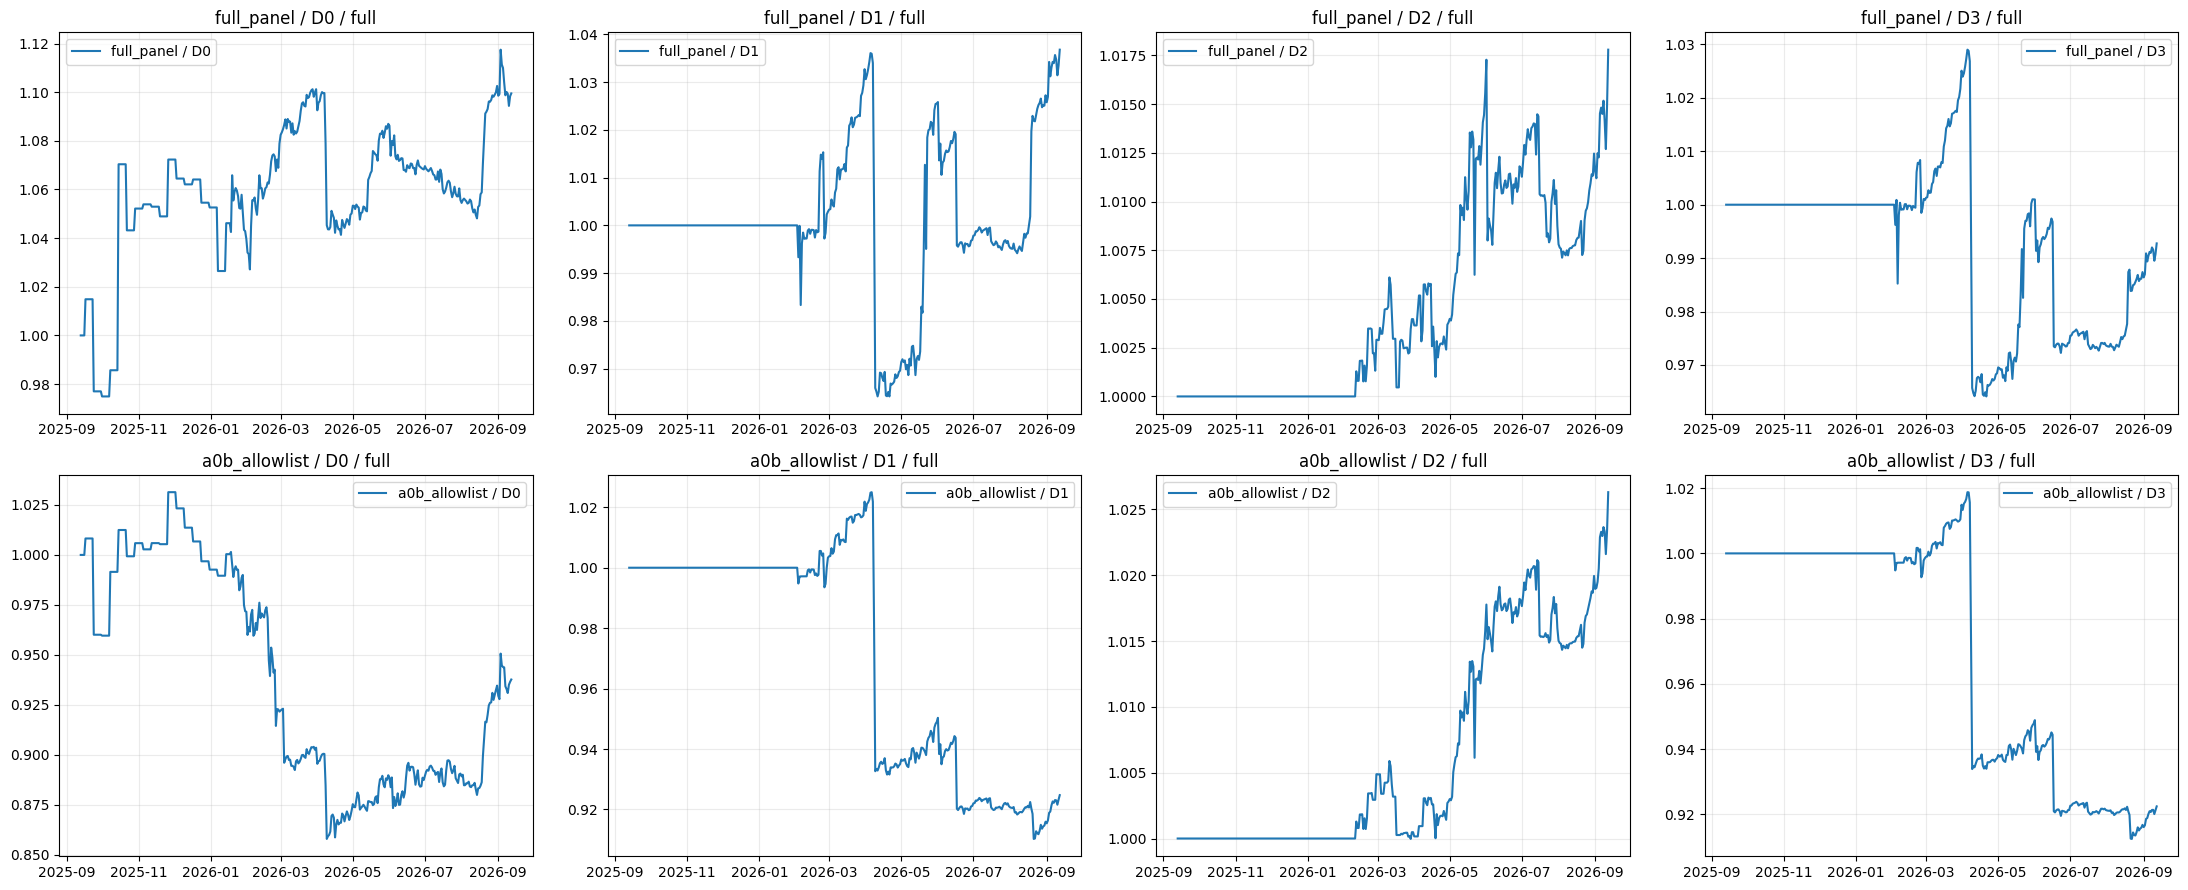

In [7]:
report = {
    "notebook": "12-research-downside-and-stress-selection.ipynb",
    "parent": "NB11 P1 frozen; D0 inherits saved P1 selection",
    "arms": list(ARMS),
    "risk_windows_days": list(RISK_WINDOWS),
    "d1_rule": "P1 and observed drawdown >= -3%, longest available 60/30/14-day daily window",
    "d2_rule": "D1 and observed annualised daily volatility <= 8%, longest available 60/30/14-day dense window",
    "d3_rule": "D1 basket; halve requested weight after observed causal 180-day drawdown below -8%; released capital remains cash",
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "starting_cash": INITIAL_CASH,
    "target_deployment": TARGET_DEPLOYMENT,
    "max_weight": MAX_WEIGHT,
    "max_tvl_fraction": MAX_TVL_FRACTION,
    "execution_every_days": EXECUTION_EVERY_DAYS,
    "blocked_addresses": len(BLOCKED),
    "blocked_holder_policy": "retain an already held blocked position and let it consume capital; no blocked positions were expected in the D0 parity control",
    "universe_counts": {name: len(addresses) for name, addresses in UNIVERSES.items()},
    "fees": "none added; observable NAV share prices are the accounting input",
    "missing_policy": "missing downside or volatility evidence does not pass D1/D2 and is reported separately; no zero-risk imputation",
    "survivorship_warning": "A0b allowlist is a retrospective snapshot; full-panel sensitivity is required",
    "backtest_metrics": backtest_metrics.to_dict(orient="records"),
    "pass_rate_rows": len(pass_rates),
}
(OUT / "nb12-report.json").write_text(json.dumps(report, indent=2, default=str))

fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=False)
for axis, ((universe_name, arm), selection) in zip(axes.flat, [(key, value) for key, value in SELECTIONS.items() if key[1] in ("D0", "D1", "D2", "D3")]):
    curve = pd.read_parquet(OUT / f"equity-{universe_name}-{arm}-full.parquet")
    axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=f"{universe_name} / {arm}")
    axis.set_title(f"{universe_name} / {arm} / full")
    axis.grid(alpha=.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "downside-stress-equity-curves.png", dpi=130)
plt.show()
